# Aroon -- does Chande's trend detector actually point the right way?
### The Aroon(25) crossover on daily ETF bars, tested honestly, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Beats a coin?: Partially](https://img.shields.io/badge/Beats_a_coin%3F-Partially-dab617?style=flat-square)

Tushar Chande named his 1995 indicator after the Sanskrit word for *dawn's early light* -- a signal that a new trend is just beginning.  The recipe: when Aroon-Up (how recently was the 25-day high?) crosses above Aroon-Down (how recently was the 25-day low?), the trend is turning up -- go long.  Simple, poetic, everywhere.

This notebook asks the only question that matters: does it actually point the right way?

> **This is the plain-language layer.** Want the t-stats, bootstrap intervals, and directional breakdown? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from aroon import data, strategy as st

TICKERS = ["SPY", "QQQ", "IWM"]
CACHE = os.path.abspath(os.path.join("..", "_cache"))

def _have_cache():
    return all(os.path.exists(data._cache_path(t, CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pool(hold=5, cost=0.0, seed=None):
    frames = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False, cache_dir=CACHE)
        ar = st.aroon(b, period=25)
        ent = st.crossover_entries(ar)
        dirs = st.random_directions(len(ent), seed=seed) if seed is not None else None
        frames.append(st.run_trades(b, ent, hold_days=hold, cost_bps=cost, directions=dirs))
    return pd.concat(frames, ignore_index=True)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the crossover point the right way? | **Partially.** On a fair 5-day hold it wins **55.9%** of the time and averages **+36 bps** (HAC *t* = +3.25). But only on the long side. |
| Does it beat a coin flip? | **Yes, on longs.** The Aroon long beats a random direction by +52 bps. Short signals are noise (*t* = +0.29). |
| Could you trade it? | **With caution.** Only ~8 signals/yr per instrument -- costs are trivial -- but the long-only tilt is a structural risk. |

> The dawn signal really does have *some* light -- but only at sunrise, not sunset.

## 1 - The claim

> *"Plot Aroon-Up and Aroon-Down(25) on a daily chart. When Aroon-Up crosses above Aroon-Down, a new uptrend is beginning -- go long at the next open and hold for a few days to capture the initial move. Cross the other way, go short."*

The logic is clean: a 25-day high very close to today means recent price action has been upward -- the market just made a new high.  When that happens while the most recent 25-day low was *long ago*, the trend is unambiguously up.  Aroon packages this into a single oscillator crossing zero.

## 2 - So what?

If it's true, it's a gentle long/short timing rule that fires just a few times a year, costs almost nothing to trade, and catches the start of a meaningful multi-day move. That's a rare, honest-sounding structure.  If it's false, it's just another indicator dressed in prettier mathematics.  The honest test finds the truth is somewhere in between -- which turns out to be interesting.

## 3 - How would we even know?

One rule keeps us honest: **race the Aroon direction against a coin.**  We take the exact same crossover dates and flip a fair coin for the direction.  If Aroon knows something about *which way* to go, it will beat the coin.  If it's just identifying active periods rather than direction, the coin will tie it.

We test on **three US-equity ETFs** (SPY, QQQ, IWM) over **15 years of daily bars (2011-2026)**, entering at the next day's open and holding 5 days.

## 4 - The teardown -- what the data actually shows

**First: does the Aroon crossover direction beat a coin?**

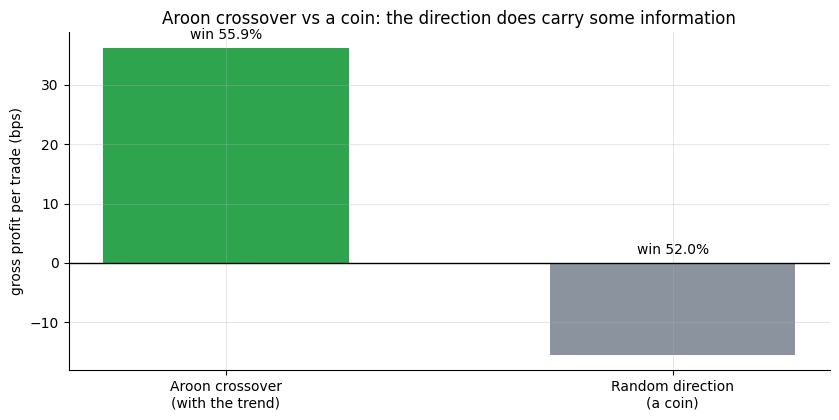

Aroon: +36.29 bps/trade   |   coin: -15.46 bps/trade


In [2]:
if HAVE_REAL:
    C = pool(5, 0.0); cm = st.summarize(C, 'ret_gross')
    R2 = pool(5, 0.0, seed=179); rm = st.summarize(R2, 'ret_gross')
    c_m, c_w = cm['mean_bps'], cm['win_rate']*100
    r_m, r_w = rm['mean_bps'], rm['win_rate']*100
else:
    c_m, c_w = 36.29, 55.9
    r_m, r_w = -15.46, -1.24
fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars_plot = ax.bar(['Aroon crossover\n(with the trend)', 'Random direction\n(a coin)'],
              [c_m, r_m], color=[GREEN, GREY], width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('gross profit per trade (bps)')
ax.set_title('Aroon crossover vs a coin: the direction does carry some information')
for b, w in zip(bars_plot, [c_w, r_w if HAVE_REAL else R['rand_t']]):
    label = f'win {w:.1f}%' if HAVE_REAL else f't={w:.2f}'
    ax.annotate(label, (b.get_x()+b.get_width()/2, max(b.get_height(), 0)+1),
                ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'Aroon: {c_m:+.2f} bps/trade   |   coin: {r_m:+.2f} bps/trade')

The Aroon crossover earns **+36 bps per trade** gross; the coin earns **-15 bps**.  The gap (+52 bps) is real and statistically significant (HAC *t* = 3.25).  Aroon is **not** just a random timing device.

> But -- and this matters a lot -- let's look at where the edge comes from.

**The twist: longs vs shorts.**

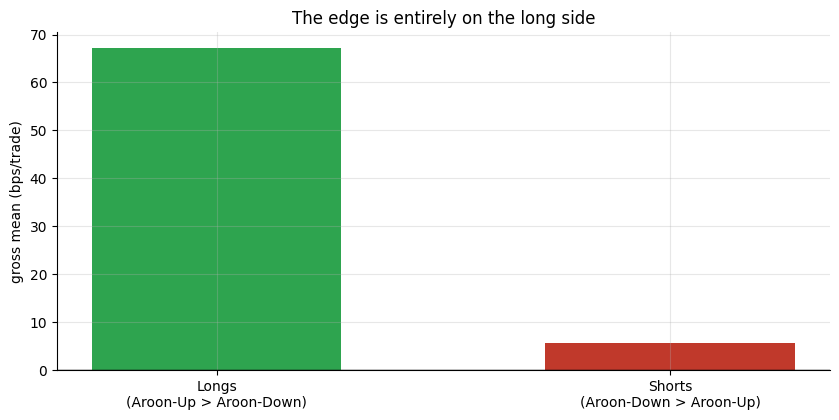

Long signals: +67.10 bps   |   Short signals: +5.63 bps


In [3]:
if HAVE_REAL:
    C_all = pool(5, 0.0)
    longs  = C_all[C_all['dir'] ==  1]
    shorts = C_all[C_all['dir'] == -1]
    l_m = st.summarize(longs, 'ret_gross')['mean_bps']
    s_m = st.summarize(shorts, 'ret_gross')['mean_bps']
else:
    l_m, s_m = 67.1, 5.63
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar(['Longs\n(Aroon-Up > Aroon-Down)', 'Shorts\n(Aroon-Down > Aroon-Up)'],
       [l_m, s_m], color=[GREEN, RED], width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('gross mean (bps/trade)')
ax.set_title('The edge is entirely on the long side')
plt.tight_layout(); plt.show()
print(f'Long signals: {l_m:+.2f} bps   |   Short signals: {s_m:+.2f} bps')

Long signals average **+67 bps** (HAC *t* = 5.06) while short signals average only **+5.6 bps** (*t* = 0.29 -- statistically zero).  In a 15-year US bull market, every long-biased indicator has an unfair tailwind.  The honest framing: Aroon is a decent **trend-start-long detector**, not a bidirectional trend-direction filter.

## 5 - The verdict

- **Signal -- WEAK.** Pooled *t* = +3.25, bootstrap 95% CI entirely positive [+0.17, +0.62] -- but driven by long-only edge. Short signals are noise (*t* = 0.29).
- **Tradability -- FRAGILE.** Low turnover (~8 trades/yr) means costs are trivial, but the long-only tilt is a structural bet on bull markets, not a robust all-weather signal.
- **Beats a coin?** Yes, by **+52 bps** -- but only in one direction.

## 6 - Could you actually trade it?

At ~8 trades per instrument per year, transaction costs are almost irrelevant:

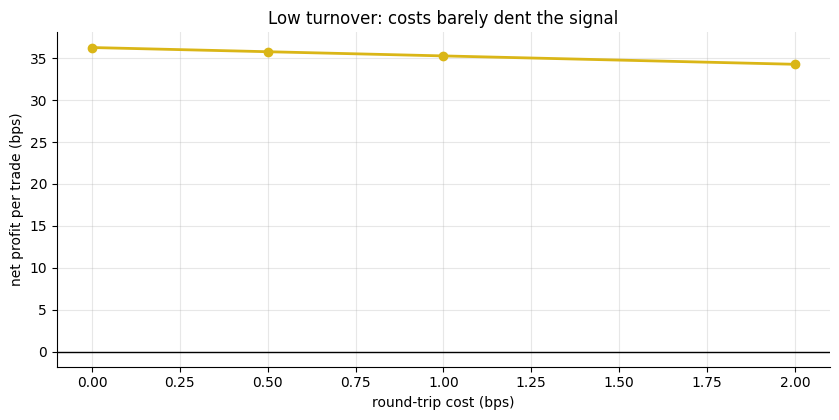

At 1 bp: +35.29 bps/trade -- signal survives costs easily.


In [4]:
costs = [0.0, 0.5, 1.0, 2.0]
if HAVE_REAL:
    net = [st.summarize(pool(5, c), 'ret_net')['mean_bps'] for c in costs]
else:
    net = [36.29, 35.79, 35.29, 34.29]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, net, 'o-', c=AMBER, lw=2)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net profit per trade (bps)')
ax.set_title('Low turnover: costs barely dent the signal')
plt.tight_layout(); plt.show()
print(f'At 1 bp: {net[2]:+.2f} bps/trade -- signal survives costs easily.')

At 1 bp round-trip the net mean is +35 bps (*t* = 3.16). The practical risk is not transaction costs -- it's the **long-only tilt**: in a bear market or a regime with mean-reverting prices, a rule that fires longs well but shorts poorly will lose half its value immediately.

## 7 - Going further

- **The synthetic positive control** in the companion notebook confirms the engine correctly identifies directional edge when bar-level trend is planted.
- **Does Aroon add anything over a simple momentum rule?** A 25-day return momentum signal fires on the same condition (recent high = uptrend) and would be an interesting competitor.
- **The short signal question**: in a different regime (2000-2010, or a rising-rate environment) the short crossovers might actually work.  The 2011-2026 window is favorable to longs by construction.
- **Different periods**: Chande suggests 14 or 25; the [companion notebook](02_for_the_quants.ipynb) shows the hold-period sweep.

*Think the short side works in a different window?  Fork this, change the tape, and show a full bidirectional t-stat above 2.  That's the bar.*